In this notebook, we demonstrate a simple modeling approuch using a linear regression on a summary of each timeseries feature

In [1]:
# import packages
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import utils #from utils import *
import more_utils
import importlib
from sklearn.linear_model import LinearRegression as LR

First let's read in the aggregated data:

In [2]:
# read in aggregated data (datafile not stored on github due to size)
agg_data = pd.read_parquet('./data/eaglei_noaa_era5_engineered.parquet')

In [4]:
agg_data.columns

Index(['fips_code', 'customers_out', 'datetime', 'YEAR', 'NAME', 'STUSPS',
       'Pct_Buried_Lines', 'neighbors', 'Subregion', 'centroid_longitude',
       'centroid_latitude', 'centroid_rounded', 'POPULATION', 'BUILDVALUE',
       'AGRIVALUE', 'AREA', 'SOVI_SCORE', 'Power_Dependent_Devices_DME_Mean',
       'event_count SnowIce', 'event_count Flood', 'event_count Storm',
       'event_count Hurricane', 'event_count Heat', 'event_count Fire',
       'event_count Wind', 'event_count Ocean', 'event_count Other', 't2m',
       'sf', 'tp', 't2m_mean', 't2m_max', 'sf_mean', 'sf_max', 'tp_mean',
       'tp_max', 'wind_speed', 'neighbor_mean_wind_speed',
       'neighbor_max_wind_speed', 'sf_12h', 'sf_24h', 'tp_12h', 'tp_24h'],
      dtype='object')

We will build our model at the county level. In our model, we will take each observation to consist of the previous 5 days of weather data, with the target being tomorrow's maximum fraction of people without power. Instead of training on timeseries observations, we summarize each timeseries feature so that the observation consists of a vector of summary features.

In [40]:
def construct_LR_model(fips, agg_data, interval_X, interval_y, make_plots, k=0):
    X_chunked, y_chunked, time_pred_start = more_utils.chunk_aggregated_engineered_data(agg_data, fips, './data', '', interval_X, interval_y)
    n_chunks = X_chunked.shape[2]
    n_features = X_chunked.shape[1]
    X_simple = np.zeros((n_chunks, 2*n_features + 3))
    y_simple = np.zeros(n_chunks)
    
    # summarize timeseries observations
    for i in range(n_chunks):
        now_datetime = time_pred_start[i] # time that we are predicting out from for this chunk        
        X_simple[i,:n_features] = np.sum(X_chunked[:,:,i], axis = 0) # total of each event in the last 4 days
        X_simple[i,n_features:] = np.mean(X_chunked[:10,:,i]) - np.mean(X_chunked[-10:,:,i]) # measure of magnitude and sign of trend over the 4 days
        X_simple[i,-3] =  np.max(y_chunked[:,:,i-2]) # what max fraction of people were without power yesterday
        X_simple[i,-2] =  np.max(y_chunked[:,:,i-1]) # what max fraction of people were without power today    
        X_simple[i,-1] =  now_datetime.to_numpy() # we will drop before training, but want to preserve during train-test split   
        y_simple[i] = np.max(y_chunked[:,:,i]) # max number of people w/o power over the next day

    # remove Nan chunks (occasionally data was not recorded for a county over a specific interval)
    X_simple = pd.DataFrame(X_simple)#, columns = cols)#.shape
    not_nan_idxs = np.invert(X_simple.isna().any(axis=1))
    X_simple = X_simple[not_nan_idxs] # remove Nan rows
    y_simple = y_simple[not_nan_idxs] 
    n_chunks_total = len(y_simple)
    
    # split into training-validation and test sets (most recent into test set)
    n_chunks_train_val = int(n_chunks_total*0.9)
    X_train_val = X_simple.iloc[0:n_chunks_train_val,:]
    y_train_val = y_simple[0:n_chunks_train_val]
    X_test = X_simple.iloc[n_chunks_train_val:,:]
    y_test = y_simple[n_chunks_train_val:]    
    n_chunks_test = len(y_test)
    
    # collect datetimes and drop from X
    train_val_datetimes = X_train_val.iloc[:,-1]
    test_datetimes = X_test.iloc[:,-1]
    X_train_val = X_train_val.iloc[:,:-1]
    X_test = X_test.iloc[:,:-1]
    
    # Cross validation: train on first N chunks, validate on chunks N:N+5, iterate
    N = 50
    n_val = 5
    val_true = np.array([])
    val_preds = np.array([])
    train_true = np.array([])
    train_preds = np.array([])
    for j in range(int(n_chunks_total/N)-1):
        # train-validation split
        X_train = X_train_val.iloc[j*N:(j+1)*N - n_val, :] # jth set of chunks, minus validation subset of chunks
        y_train = y_train_val[j*N:(j+1)*N - n_val] # jth set of chunks, minus validation subset of chunks
        X_val = X_train_val.iloc[(j+1)*N - n_val:(j+1)*N, :]
        y_val = y_train_val[(j+1)*N - n_val:(j+1)*N]
        # fit model
        reg = LR().fit(X_train, y_train)
        y_pred_train = reg.predict(X_train)
        y_pred_val = reg.predict(X_val)
        # restrict the range of outputs, because the target is a fraction and can physically range from 0-1 only
        y_pred_train[y_pred_train > 1] = 1
        y_pred_train[y_pred_train < 0] = 0
        y_pred_val[y_pred_val > 1] = 1
        y_pred_val[y_pred_val < 0] = 0
        # append predictions
        train_true = np.append(train_true, y_train) #+= [y_train]
        train_preds = np.append(train_preds, y_pred_train) #+= [y_pred_train]
        val_true = np.append(val_true, y_val) #+= [y_val]
        val_preds = np.append(val_preds, y_pred_val) #+= [y_pred_val]
        
    # calculate overall RMSE over training set
    train_RMSE = np.sqrt(np.mean((train_true - train_preds)**2))
    print('   Training RMSE: ' + str(train_RMSE))
    
    # calculate overall RMSE over validation set
    val_RMSE = np.sqrt(np.mean((val_true - val_preds)**2))
    print('   Validation RMSE: ' + str(val_RMSE))
    
    if make_plots:
        plt.subplot(n_counties, 2, k)
        index = np.linspace(0,len(train_preds) -1,len(train_preds))
        plt.plot(index, train_true, label = 'training data')
        plt.plot(index, train_preds, label = 'training predictions')
        plt.xlabel(str(n_days_X)+'-day chunk index')
        plt.ylabel('max fraction without power tomorrow')
        plt.title('fips code: ' + str(fips))
        plt.legend()
        k += 1
        plt.subplot(n_counties, 2, k)
        index = np.linspace(0,len(val_preds) -1,len(val_preds))
        plt.plot(index, val_true, label = 'validation data')
        plt.plot(index, val_preds, label = 'validation predictions')
        plt.xlabel(str(n_days_X)+'-day chunk index')
        plt.ylabel('max fraction without power tomorrow')
        plt.legend()
        plt.title('fips code: ' + str(fips))
        
    return train_RMSE, val_RMSE

Training model for county fips: 29067
   Training RMSE: 0.002824086392821126
   Validation RMSE: 0.02260588910105417
Training model for county fips: 53033
   Training RMSE: 0.002626026017337316
   Validation RMSE: 0.0033057039759706057


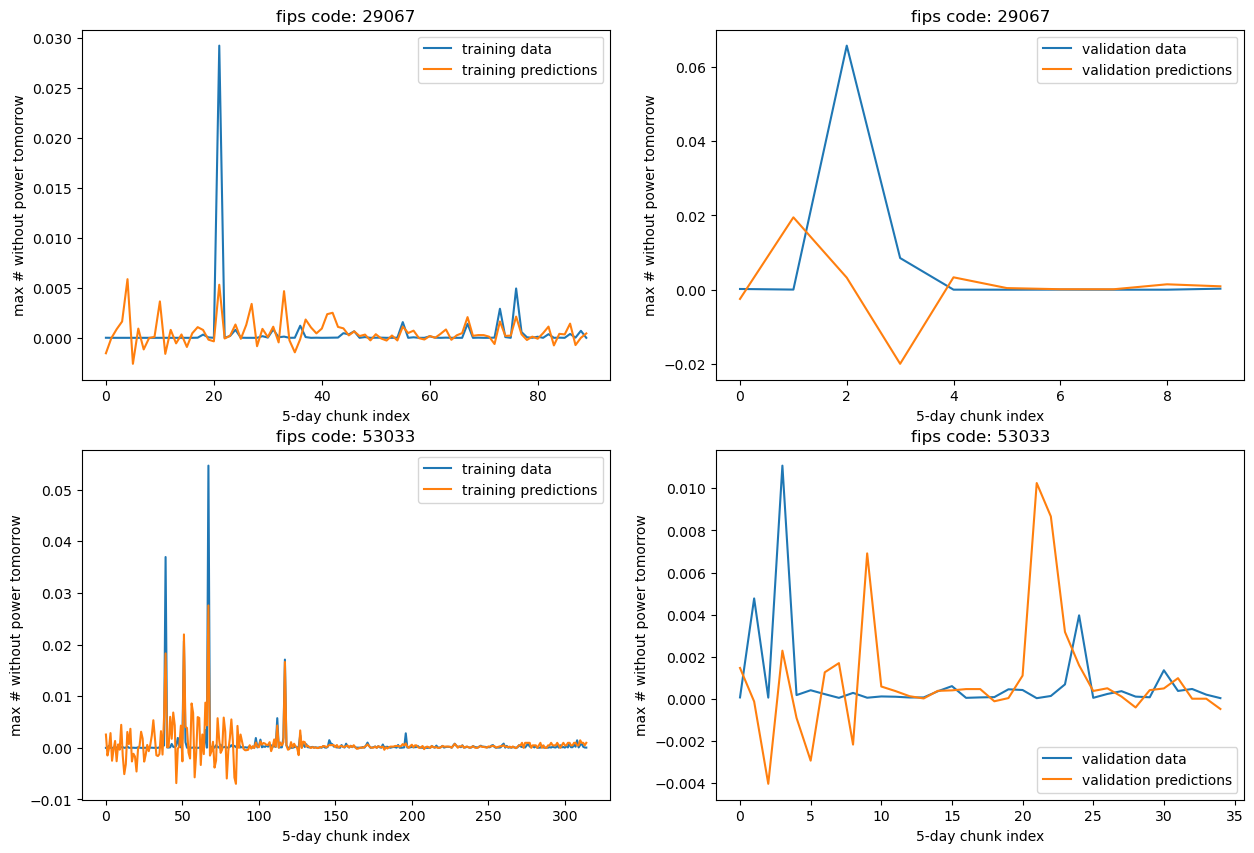

In [11]:
# choose a list of fips (county) codes to build models for. We will build a differnt model for each county.
# as one example, let's do Providence and Seattle
all_fips = list(set(agg_data['fips_code']))
fips_list = [29067, 53033] 
n_counties = len(fips_list)

# choose how long the training interval should be
n_days_X = 5
interval_X = int((24/6)*n_days_X) # 5 previous days, at 6 hr cadence
interval_y = int(24/6*1) # tomorrow

# whether or not to plot the predictions
make_plots = True
if make_plots:
    plt.figure(figsize = [15,5*n_counties])
    k = 1

# loop over and build a model for each county
county_train_RMSEs = []
county_val_RMSEs = []
for j in range(len(fips_list)):
    fips = fips_list[j]
    print('Training model for county fips: ' + str(fips))
    
    # train and predict 
    train_RMSE, val_RMSE = construct_LR_model(fips, agg_data, interval_X, interval_y, make_plots, k)
    county_val_RMSEs += [val_RMSE]
    county_train_RMSEs += [train_RMSE]  
    print('Mean training RMSE:', ')
    if make_plots:
        k+=2


We perform much better on the training data than the validation data, which means we should suspect overfitting. We are limited though by the sparsity of some weather events.

To compare to the other models, let's see how we do on the full set of counties we are considering:

In [15]:
states = ['ME', 'OR', 'AZ', 'NE', 'SC', 'NJ', 'MS', 'MT', 'IA', 'CO']
stats_fips_prefixes = ['23', '41', '04', '31', '34', '28',  '30', '19', '08']

fips_list = [fips for fips in all_fips if str(fips).startswith(tuple(stats_fips_prefixes))]

In [41]:
n_counties = len(fips_list)
make_plots = False

# loop over and build amodel for each county
county_train_RMSEs = []
county_val_RMSEs = []
for j in range(len(fips_list)):
    fips = fips_list[j]
    print('Training model for county fips: ' + str(fips))
    
    # train and predict 
    train_RMSE, val_RMSE = construct_LR_model(fips, agg_data, interval_X, interval_y, make_plots, k)
    county_val_RMSEs += [val_RMSE]
    county_train_RMSEs += [train_RMSE]
    if make_plots:
        k+=2


Training model for county fips: 41001
   Training RMSE: 0.0038097297773961192
   Validation RMSE: 0.01633256008906939
Training model for county fips: 41003
   Training RMSE: 0.001506153186913114
   Validation RMSE: 0.23306116055180068
Training model for county fips: 41005
   Training RMSE: 0.0012506662545950262
   Validation RMSE: 0.010293266893809728
Training model for county fips: 41007
   Training RMSE: 0.003494678017371698
   Validation RMSE: 0.33993477550038065
Training model for county fips: 41009
   Training RMSE: 2.296872826081477e-05
   Validation RMSE: 0.2000001115248652
Training model for county fips: 41011
   Training RMSE: 0.0032826442222159934
   Validation RMSE: 0.2828201938565025
Training model for county fips: 41013
   Training RMSE: 0.0013248365355694347
   Validation RMSE: 0.0064858435607413585
Training model for county fips: 41015
   Training RMSE: 0.004752330553522702
   Validation RMSE: 0.002298638226630783
Training model for county fips: 41017
   Training RMSE: 0

In [42]:
# calculate mean RMSEs
mean_train_RMSE = np.nanmean(county_train_RMSEs)
print('Mean training RMSE:', mean_train_RMSE )
mean_val_RMSE = np.nanmean(county_val_RMSEs)
print('Mean validation RMSE:', mean_val_RMSE )

Mean training RMSE: 0.0020535634555805655
Mean validation RMSE: 0.019674078475904


### Performance on test data

The following section was NOT used in model tuning or in deciding which final model to use. This was only run AFTER a final model was selected (not this model), just so that we can see performance on the unseen test set. No test data was used in any model construction or selection.

In [70]:
# concatenate all chunked training data
X_chunked_all = np.zeros((interval_X, n_features, 0))
y_chunked_all = np.zeros((interval_y, 1, 0))
for j in range(len(fips_list)):
    fips = fips_list[j]
    X_chunked_fips, y_chunked_fips, time_pred_start_fips = more_utils.chunk_aggregated_engineered_data(agg_data, fips, './data', '', interval_X, interval_y)
    X_chunked_all = np.append(X_chunked_all, X_chunked_fips, axis = 2)
    y_chunked_all = np.append(y_chunked_all, y_chunked_fips, axis = 2)

print(X_chunked_all.shape)
print(y_chunked_all.shape)

(20, 36, 194881)
(4, 1, 194881)


In [72]:

n_chunks = X_chunked_all.shape[2]
n_features = X_chunked_all.shape[1]
X_simple = np.zeros((n_chunks, 2*n_features + 3))
y_simple = np.zeros(n_chunks)

# summarize timeseries observations
for i in range(n_chunks):
    X_simple[i,:n_features] = np.sum(X_chunked_all[:,:,i], axis = 0) # total of each event in the last 4 days
    X_simple[i,n_features:] = np.mean(X_chunked_all[:10,:,i]) - np.mean(X_chunked_all[-10:,:,i]) # measure of magnitude and sign of trend over the 4 days
    X_simple[i,-3] =  np.max(y_chunked_all[:,:,i-2]) # what max fraction of people were without power yesterday
    X_simple[i,-2] =  np.max(y_chunked_all[:,:,i-1]) # what max fraction of people were without power today    
    X_simple[i,-1] =  now_datetime.to_numpy() # we will drop before training, but want to preserve during train-test split   
    y_simple[i] = np.max(y_chunked_all[:,:,i]) # max number of people w/o power over the next day

# remove Nan chunks (occasionally data was not recorded for a county over a specific interval)
X_simple = pd.DataFrame(X_simple)#, columns = cols)#.shape
not_nan_idxs = np.invert(X_simple.isna().any(axis=1))
X_simple = X_simple[not_nan_idxs] # remove Nan rows
y_simple = y_simple[not_nan_idxs] 
n_chunks_total = len(y_simple)

# split into training-validation and test sets (most recent 10% into test set)
n_chunks_train = int(n_chunks_total*0.9)
X_train = X_simple.iloc[0:n_chunks_train,:]
y_train = y_simple[0:n_chunks_train]
X_test = X_simple.iloc[n_chunks_train:,:]
y_test = y_simple[n_chunks_train:]    
n_chunks_test = len(y_test)

# collect datetimes and drop from X
train_val_datetimes = X_train_val.iloc[:,-1]
test_datetimes = X_test.iloc[:,-1]
X_train = X_train.iloc[:,:-1]
X_test = X_test.iloc[:,:-1]

# train on all training data, predict on test data
reg = LR().fit(X_train, y_train)
y_pred_train = reg.predict(X_train)
y_pred_test = reg.predict(X_test)
# restrict the range of outputs, because the target is a fraction and can physically range from 0-1 only
y_pred_train[y_pred_train > 1] = 1
y_pred_train[y_pred_train < 0] = 0
y_pred_test[y_pred_test > 1] = 1
y_pred_test[y_pred_test < 0] = 0

train_RMSE = np.sqrt(np.mean((y_train - y_pred_train)**2))
print('   Full training RMSE: ' + str(train_RMSE))

test_RMSE = np.sqrt(np.mean((y_test - y_pred_test)**2))
print('   Test RMSE: ' + str(test_RMSE))

   Full training RMSE: 0.0067923749787547364
   Test RMSE: 0.01573364582894728
